# 🎬 Content-Based Movie Recommendation System

### An Unsupervised Machine Learning Project using the TMDB 5000 Dataset

---

## 1. Project Introduction

### What is a movie recommendation system?
A recommendation system suggests items (in our case, movies) that a user is likely to enjoy. Instead of the user searching through thousands of titles, the system narrows it down to a handful of relevant suggestions.

### Why are recommendation systems useful?
- They save the user time
- They help users discover content they wouldn't have found on their own
- They increase engagement on streaming/e-commerce platforms

### What problem does our system solve?
Given a movie a user already likes, our system finds and recommends other movies that are **similar in content** — similar genre, story, cast, and director.

### Types of Recommendation Systems

```
Recommendation Systems
        |
        |---- Collaborative Filtering   (uses OTHER users' behavior/ratings)
        |
        |---- Content-Based Filtering   (uses the ITEM's own attributes)
        |
        |---- Hybrid Recommendation     (combination of both)
```

**This project uses Content-Based Filtering**, because our dataset only describes the movies themselves (genre, cast, overview, etc.) — we do not have any user rating/interaction data to build a collaborative filter.

### What type of Machine Learning is this?
This is an **Unsupervised Machine Learning** project. We do not have a target/label column such as `recommended = 1` or `recommended = 0`. Instead, the model discovers relationships between movies purely by comparing their features to one another.

### Final Objective

```
Select Movie
     ↓
System analyzes movie features
     ↓
Find similar movies
     ↓
Return Top 5 recommendations
```


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import pickle
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

sns.set_style('whitegrid')
%matplotlib inline


## 2. Load the Dataset

We have two files:
- `tmdb_5000_movies.csv` — movie details (genres, overview, budget, revenue, etc.)
- `tmdb_5000_credits.csv` — cast & crew details for each movie


In [2]:
movies = pd.read_csv('../data/tmdb_5000_movies.csv')
credits = pd.read_csv('../data/tmdb_5000_credits.csv')


### 2.1 Dataset Understanding

Let's look at the shape, columns and basic info of both dataframes.

In [3]:
movies.head()


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 878, ""name"": ""Science Fiction""}]",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"": 2964, ""name"": ""future""}, {""id"": 3386, ""name"": ""space war""}, {""id"": 3388, ""name"": ""space colony""}, {""id"": 3679, ""name"": ""society""}, {""id"": 3801, ""name"": ""space travel""}, {""id"": 9685, ""name"": ""futuristic""}, {""id"": 9840, ""name"": ""romance""}, {""id"": 9882, ""name"": ""space""}, {""id"": 9951, ""name"": ""alien""}, {""id"": 10148, ""name"": ""tribe""}, {""id"": 10158, ""name"": ""alien planet""}, {""id"": 10987, ""name"": ""cgi""}, {""id"": 11399, ""name"": ""marine""}, {""id"": 13065, ""name"": ""soldier""}, {""id"": 14643, ""name"": ""battle""}, {""id"": 14720, ""name"": ""love affair""}, {""id"": 165431, ""name"": ""anti war""}, {""id"": 193554, ""name"": ""power relations""}, {""id"": 206690, ""name"": ""mind and soul""}, {""id"": 209714, ""name"": ""3d""}]",en,Avatar,"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289}, {""name"": ""Twentieth Century Fox Film Corporation"", ""id"": 306}, {""name"": ""Dune Entertainment"", ""id"": 444}, {""name"": ""Lightstorm Entertainment"", ""id"": 574}]","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}, {""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""name"": ""Fantasy""}, {""id"": 28, ""name"": ""Action""}]",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""name"": ""drug abuse""}, {""id"": 911, ""name"": ""exotic island""}, {""id"": 1319, ""name"": ""east india trading company""}, {""id"": 2038, ""name"": ""love of one's life""}, {""id"": 2052, ""name"": ""traitor""}, {""id"": 2580, ""name"": ""shipwreck""}, {""id"": 2660, ""name"": ""strong woman""}, {""id"": 3799, ""name"": ""ship""}, {""id"": 5740, ""name"": ""alliance""}, {""id"": 5941, ""name"": ""calypso""}, {""id"": 6155, ""name"": ""afterlife""}, {""id"": 6211, ""name"": ""fighter""}, {""id"": 12988, ""name"": ""pirate""}, {""id"": 157186, ""name"": ""swashbuckler""}, {""id"": 179430, ""name"": ""aftercreditsstinger""}]",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""Jerry Bruckheimer Films"", ""id"": 130}, {""name"": ""Second Mate Productions"", ""id"": 19936}]","[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""name"": ""Adventure""}, {""id"": 80, ""name"": ""Crime""}]",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name"": ""based on novel""}, {""id"": 4289, ""name"": ""secret agent""}, {""id"": 9663, ""name"": ""sequel""}, {""id"": 14555, ""name"": ""mi6""}, {""id"": 156095, ""name"": ""british secret service""}, {""id"": 158431, ""n

In [4]:
print('movies shape:', movies.shape)
movies.info()


movies shape: (4803, 20)
<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  status 

In [5]:
movies.describe()


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.803000e+03,4803.000000,4803.000000,4.803000e+03,4801.000000,4803.000000,4803.000000
mean,2.904504e+07,57165.484281,21.492301,8.226064e+07,106.875859,6.092172,690.217989
std,4.072239e+07,88694.614033,31.816650,1.628571e+08,22.611935,1.194612,1234.585891
min,0.000000e+00,5.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,7.900000e+05,9014.500000,4.668070,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14629.000000,12.921594,1.917000e+07,103.000000,6.200000,235.000000
75%,4.000000e+07,58610.500000,28.313505,9.291719e+07,118.000000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [6]:
credits.head()


movie_id  ...                                               crew
0     19995  ...  [{"credit_id": "52fe48009251416c750aca23", "de...
1       285  ...  [{"credit_id": "52fe4232c3a36847f800b579", "de...
2    206647  ...  [{"credit_id": "54805967c3a36829b5002c41", "de...
3     49026  ...  [{"credit_id": "52fe4781c3a36847f81398c3", "de...
4     49529  ...  [{"credit_id": "52fe479ac3a36847f813eaa3", "de...

[5 rows x 4 columns]

In [7]:
print('credits shape:', credits.shape)
credits.info()


credits shape: (4803, 4)
<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   movie_id  4803 non-null   int64
 1   title     4803 non-null   str  
 2   cast      4803 non-null   str  
 3   crew      4803 non-null   str  
dtypes: int64(1), str(3)
memory usage: 150.2 KB


**Observations:**
- `movies` has 4803 rows and 20 columns — a mix of numerical (`budget`, `popularity`, `revenue`, `runtime`, `vote_average`, `vote_count`), categorical (`status`, `original_language`) and text/JSON-like columns (`genres`, `keywords`, `overview`, `production_companies`).
- `credits` has 4803 rows and 4 columns: `movie_id`, `title`, `cast`, `crew` (the last two are JSON-like text).


## 3. Data Cleaning

### 3.1 Missing Values
Let's check which columns have missing values.


In [8]:
movies.isnull().sum()[movies.isnull().sum() > 0]


homepage        3091
overview           3
release_date       1
runtime            2
tagline          844
dtype: int64

**Which missing values matter for us?**
- `homepage` and `tagline` — not used for content-based recommendations, safe to ignore
- `overview` — a few rows are missing this; since `overview` is a key content feature, we will drop those specific rows later
- `runtime` — a couple of missing values, not critical for the recommender itself
- `release_date` — one missing value, only used for EDA (release year)

We do **not** blindly drop entire columns — only columns/rows that are truly unusable for our goal are removed.


### 3.2 Duplicate Records

In [9]:
print('Duplicate rows in movies:', movies.duplicated().sum())
print('Duplicate rows in credits:', credits.duplicated().sum())


Duplicate rows in movies: 0
Duplicate rows in credits: 0


There are no duplicate rows here, but in general duplicates should be removed because they would make the same movie appear more than once and bias the similarity matrix.

## 4. Merge the Datasets

`movies.id` and `credits.movie_id` refer to the same movie, so we merge on this key. After merging we get cast and crew information alongside all movie metadata in a single dataframe.


In [10]:
movies = movies.merge(credits, left_on='id', right_on='movie_id')

# after merging we get both title_x (from movies) and title_y (from credits)
# they contain the same value, so we keep only one
movies['title'] = movies['title_x']
movies.drop(columns=['title_x', 'title_y'], inplace=True)

print(movies.shape)
movies.columns.tolist()


(4803, 23)


['budget', 'genres', 'homepage', 'id', 'keywords', 'original_language', 'original_title', 'overview', 'popularity', 'production_companies', 'production_countries', 'release_date', 'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'vote_average', 'vote_count', 'movie_id', 'cast', 'crew', 'title']

In [11]:
movies.duplicated().sum()


np.int64(0)

In [12]:
movies.dropna(subset=['overview', 'genres', 'keywords'], inplace=True)
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_year'] = movies['release_date'].dt.year
print('Shape after cleaning:', movies.shape)


Shape after cleaning: (4800, 24)


## 5. Feature Selection

Not every column is useful for a **content-based** recommender. We split columns into two groups:

**Content Features** (used to compute similarity):
- `genres`, `keywords`, `overview`, `cast`, `crew` (director)

**Supporting Features** (used for EDA / context, not for similarity):
- `popularity`, `vote_average`, `vote_count`, `release_date`, `runtime`

We ignore columns like `homepage`, `production_companies`, `production_countries`, `spoken_languages` and `tagline` because they do not describe the *content/story* of the movie in a way that helps find similar movies.


## 6. Exploratory Data Analysis (EDA)

We will look at genres, ratings, popularity, budget vs revenue, rating vs popularity, movie status, release year and runtime.


### 6.1 Genre Analysis — Bar Chart

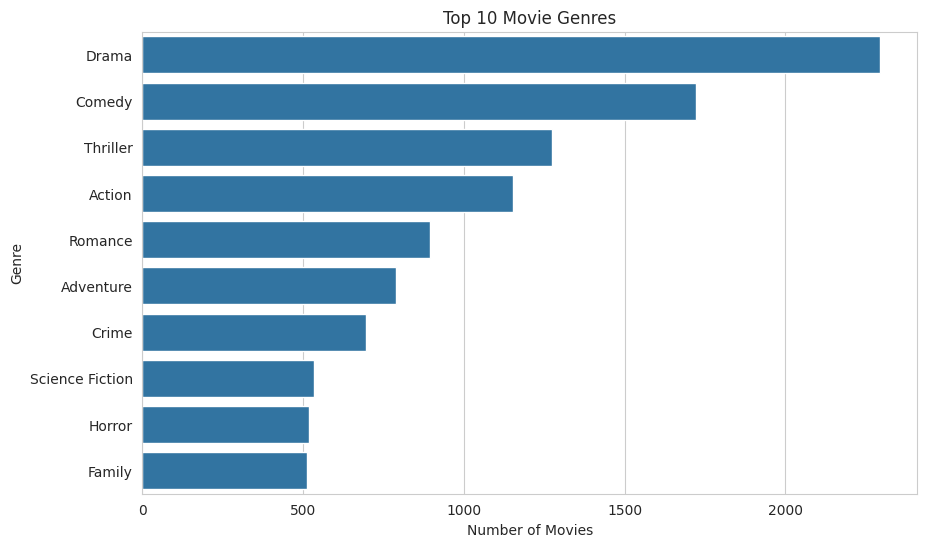

In [13]:
def safe_literal_list(x):
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        return []

all_genres = []
for row in movies['genres']:
    for g in safe_literal_list(row):
        all_genres.append(g['name'])

genre_counts = pd.Series(all_genres).value_counts().head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Top 10 Movie Genres')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()


**Insight:** Drama and Comedy are by far the most common genres in the dataset, followed by Thriller and Action. This tells us the dataset leans heavily towards mainstream, story-driven films.

### 6.2 Vote Average Distribution — Histogram

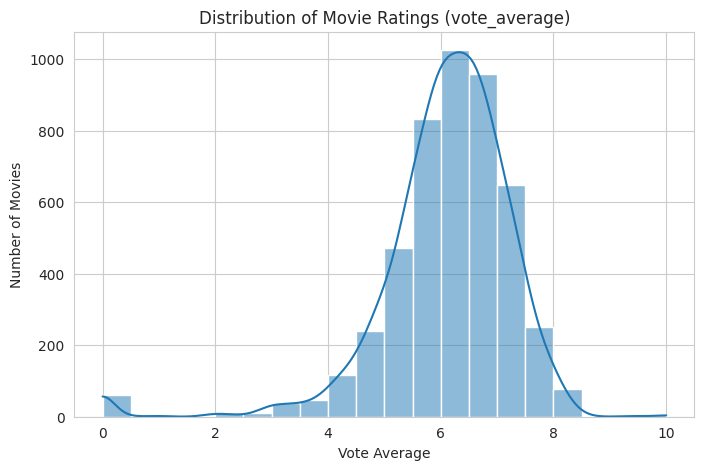

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(movies['vote_average'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings (vote_average)')
plt.xlabel('Vote Average')
plt.ylabel('Number of Movies')
plt.show()


**Insight:** Ratings are roughly centered around 6, with a slightly left-skewed (longer tail toward low ratings) shape. Very few movies score above 8 or below 3 — most movies cluster in the 'average to good' range.

### 6.3 Popularity — Box Plot

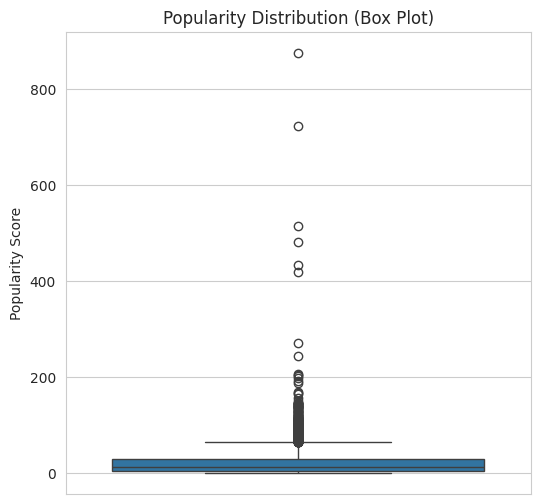

In [15]:
plt.figure(figsize=(6, 6))
sns.boxplot(y=movies['popularity'])
plt.title('Popularity Distribution (Box Plot)')
plt.ylabel('Popularity Score')
plt.show()


**Insight:** Popularity has many extreme outliers — a handful of blockbuster movies (e.g. major franchise films) have popularity scores far higher than the rest, while most movies sit close to 0. This is expected: popularity is driven by a small number of very high-profile releases.

### 6.4 Budget vs Revenue — Scatter Plot

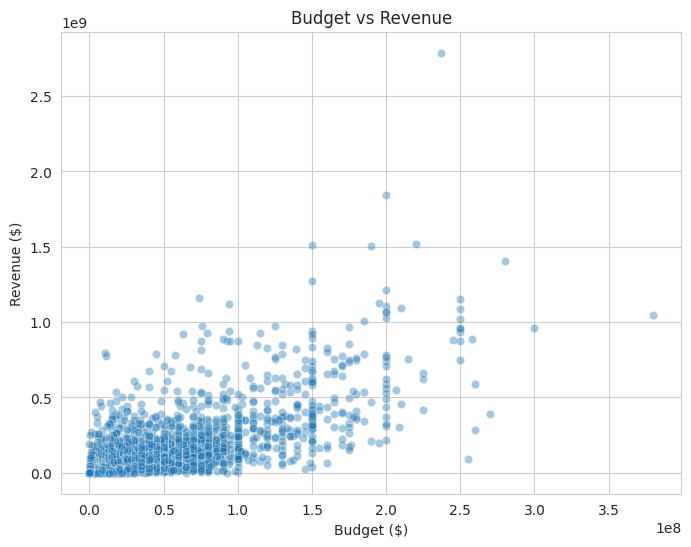

In [16]:
plot_df = movies[(movies['budget'] > 0) & (movies['revenue'] > 0)]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x='budget', y='revenue', alpha=0.4)
plt.title('Budget vs Revenue')
plt.xlabel('Budget ($)')
plt.ylabel('Revenue ($)')
plt.show()


**Insight:** There is a general positive trend — bigger budgets tend to correlate with bigger revenue. However, there is a lot of scatter: some low-budget movies earn very high revenue, and some big-budget movies underperform. Correlation here does **not** imply causation — many other factors (marketing, story quality, timing) affect revenue.

### 6.5 Rating vs Popularity — Scatter Plot

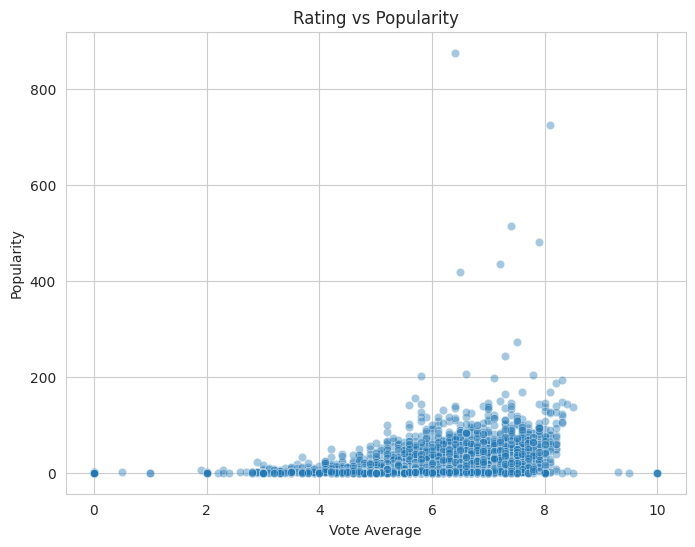

In [17]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=movies, x='vote_average', y='popularity', alpha=0.4)
plt.title('Rating vs Popularity')
plt.xlabel('Vote Average')
plt.ylabel('Popularity')
plt.show()


**Insight:** High popularity does not always mean high rating, and vice-versa. A movie can be extremely popular (widely watched/talked about) while having only an average rating — popularity measures *attention*, rating measures *quality as perceived by voters*. These are different things.

### 6.6 Movie Status — Pie Chart

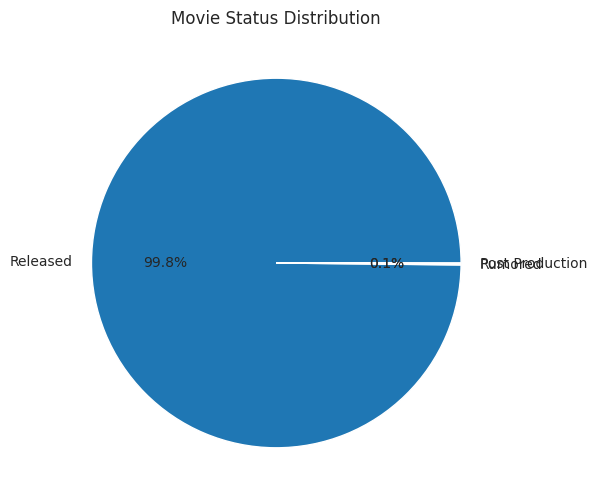

In [18]:
status_counts = movies['status'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%')
plt.title('Movie Status Distribution')
plt.show()


**Insight:** The overwhelming majority of movies in the dataset are already `Released`, with only a tiny fraction in `Post Production` or `Rumored` status.

### 6.7 Release Year Trend

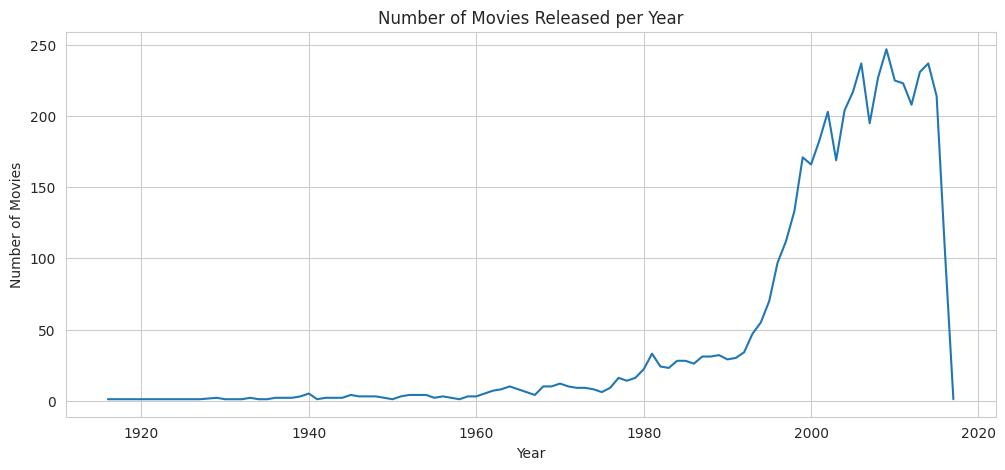

In [19]:
movies_per_year = movies['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
movies_per_year.plot(kind='line')
plt.title('Number of Movies Released per Year')
plt.xlabel('Year')
plt.ylabel('Number of Movies')
plt.show()


**Insight:** The number of movies released per year grows steadily and rises sharply after the 1990s-2000s, reflecting the general growth of the film industry and increased data availability for recent years.

### 6.8 Runtime — Box Plot

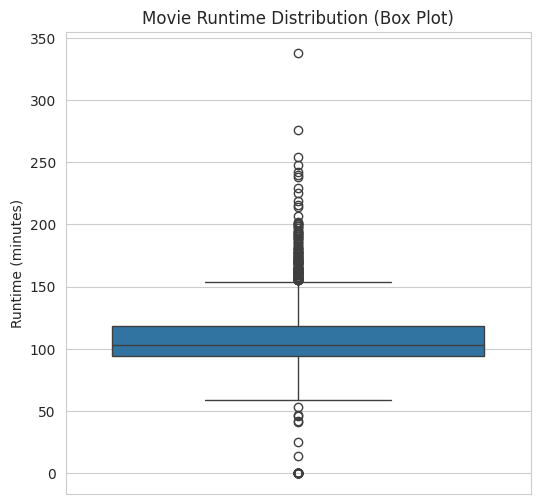

In [20]:
plt.figure(figsize=(6, 6))
sns.boxplot(y=movies['runtime'].dropna())
plt.title('Movie Runtime Distribution (Box Plot)')
plt.ylabel('Runtime (minutes)')
plt.show()


**Insight:** Most movies run between about 90 and 120 minutes, which matches typical industry standards for feature films. There are a few long outliers (over 180 minutes) and a few unusually short ones.

### 6.9 Top Movies by Different Metrics

In [21]:
print('Top 5 by Popularity:')
print(movies.nlargest(5, 'popularity')[['title', 'popularity']])

print('\nTop 5 by Rating:')
print(movies.nlargest(5, 'vote_average')[['title', 'vote_average']])

print('\nTop 5 by Revenue:')
print(movies.nlargest(5, 'revenue')[['title', 'revenue']])


Top 5 by Popularity:
                       title  popularity
546                  Minions  875.581305
95              Interstellar  724.247784
788                 Deadpool  514.569956
94   Guardians of the Galaxy  481.098624
127       Mad Max: Fury Road  434.278564

Top 5 by Rating:
                      title  vote_average
3519       Stiff Upper Lips          10.0
4045  Dancer, Texas Pop. 81          10.0
4247  Me You and Five Bucks          10.0
4662         Little Big Top          10.0
3992              Sardaarji           9.5

Top 5 by Revenue:
             title     revenue
0           Avatar  2787965087
25         Titanic  1845034188
16    The Avengers  1519557910
28  Jurassic World  1513528810
44       Furious 7  1506249360


**Important distinction:** 'high rating', 'high popularity' and 'high revenue' are **not the same thing**. A niche movie can have a perfect rating from very few voters, a franchise movie can be extremely popular without being the highest rated, and a blockbuster can earn huge revenue while having only an average rating.

## 7. Feature Engineering

**Feature Engineering** means creating useful input features from the raw dataset so the ML step (vectorization + similarity) can work well.

We will extract:
1. **Genres** — from JSON-like text to a clean list of words
2. **Keywords** — same idea
3. **Cast** — only the top 3 actors (the entire cast is too noisy and would dilute similarity)
4. **Director** — extracted from the `crew` column by finding the person whose job is `'Director'`
5. **Overview** — split into words (kept simple, no heavy NLP)


In [22]:
def get_names(text):
    """[{'id':28,'name':'Action'}, ...] -> ['Action', ...]"""
    return [d['name'] for d in safe_literal_list(text)]

def get_top_cast(text, n=3):
    """Return only the first n cast members."""
    names = [d['name'] for d in safe_literal_list(text)]
    return names[:n]

def get_director(text):
    """Find the person whose job is 'Director' in the crew list."""
    for d in safe_literal_list(text):
        if d.get('job') == 'Director':
            return [d['name']]
    return []

movies['genres_list'] = movies['genres'].apply(get_names)
movies['keywords_list'] = movies['keywords'].apply(get_names)
movies['cast_list'] = movies['cast'].apply(get_top_cast)
movies['director_list'] = movies['crew'].apply(get_director)

movies[['title', 'genres_list', 'keywords_list', 'cast_list', 'director_list']].head()


,title,genres_list,keywords_list,cast_list,director_list
0,Avatar,"[Action, Adventure, Fantasy, Science Fiction]","[culture clash, future, space war, space colony, society, space travel, futuristic, romance, space, alien, tribe, alien planet, cgi, marine, soldier, battle, love affair, anti war, power relations, mind and soul, 3d]","[Sam Worthington, Zoe Saldana, Sigourney Weaver]",[James Cameron]
1,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drug abuse, exotic island, east india trading company, love of one's life, traitor, shipwreck, strong woman, ship, alliance, calypso, afterlife, fighter, pirate, swashbuckler, aftercreditsstinger]","[Johnny Depp, Orlando Bloom, Keira Knightley]",[Gore Verbinski]
2,Spectre,"[Action, Adventure, Crime]","[spy, based on novel, secret agent, sequel, mi6, british secret service, united kingdom]","[Daniel Craig, Christoph Waltz, Léa Seydoux]",[Sam Mendes]
3,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dc comics, crime fighter, terrorist, secret identity, burglar, hostage drama, time bomb, gotham city, vigilante, cover-up, superhero, villainess, tragic hero, terrorism, destruction, catwoman, cat burglar, imax, flood, criminal underworld, batman]","[Christian Bale, Michael Caine, Gary Oldman]",[Christopher Nolan]
4,John Carter,"[Action, Adventure, Science Fiction]","[based on novel, mars, medallion, space travel, princess, alien, steampunk, martian, escape, edgar rice burroughs, alien race, superhuman strength, mars civilization, sword and planet, 19th century, 3d]","[Taylor Kitsch, Lynn Collins, Samantha Morton]",[Andrew Stanton]


**Why remove spaces inside names?**

If we leave `"Robert Downey Jr"` as-is, a bag-of-words vectorizer will split it into 3 separate tokens: `robert`, `downey`, `jr`. This could accidentally match another movie that just contains the word `"jr"`. So we merge each name into a single token, e.g. `RobertDowneyJr`.


In [23]:
def remove_spaces(word_list):
    return [w.replace(' ', '') for w in word_list]

movies['genres_list'] = movies['genres_list'].apply(remove_spaces)
movies['keywords_list'] = movies['keywords_list'].apply(remove_spaces)
movies['cast_list'] = movies['cast_list'].apply(remove_spaces)
movies['director_list'] = movies['director_list'].apply(remove_spaces)

# overview is a normal sentence -> split into a list of words
movies['overview_list'] = movies['overview'].apply(lambda x: str(x).split())


## 8. Create the Final `tags` Feature

We combine genres, keywords, cast, director and overview into a single `tags` column. This single text column represents "everything about the movie's content" in one place, which is what we will vectorize.


In [24]:
movies['tags_list'] = (
    movies['overview_list']
    + movies['genres_list']
    + movies['keywords_list']
    + movies['cast_list']
    + movies['director_list']
)

# Part 10: simple text normalization -> lowercase + join into a single string
movies['tags'] = movies['tags_list'].apply(lambda x: ' '.join(x).lower())

movies[['title', 'tags']].head()


,title,tags
0,Avatar,"in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver jamescameron"
1,Pirates of the Caribbean: At World's End,"captain barbossa, long believed to be dead, has come back to life and is headed to the edge of the earth with will turner and elizabeth swann. but nothing is quite as it seems. adventure fantasy action ocean drugabuse exoticisland eastindiatradingcompany loveofone'slife traitor shipwreck strongwoman ship alliance calypso afterlife fighter pirate swashbuckler aftercreditsstinger johnnydepp orlandobloom keiraknightley goreverbinski"
2,Spectre,"a cryptic message from bond’s past sends him on a trail to uncover a sinister organization. while m battles political forces to keep the secret service alive, bond peels back the layers of deceit to reveal the terrible truth behind spectre. action adventure crime spy basedonnovel secretagent sequel mi6 britishsecretservice unitedkingdom danielcraig christophwaltz léaseydoux sammendes"
3,The Dark Knight Rises,"following the death of district attorney harvey dent, batman assumes responsibility for dent's crimes to protect the late attorney's reputation and is subsequently hunted by the gotham city police department. eight years later, batman encounters the mysterious selina kyle and the villainous bane, a new terrorist leader who overwhelms gotham's finest. the dark knight resurfaces to protect a city that has branded him an enemy. action crime drama thriller dccomics crimefighter terrorist secretidentity burglar hostagedrama timebomb gothamcity vigilante cover-up superhero villainess tragichero terrorism destruction catwoman catburglar imax flood criminalunderworld batman christianbale michaelcaine garyoldman christophernolan"
4,John Carter,"john carter is a war-weary, former military captain who's inexplicably transported to the mysterious and exotic planet of barsoom (mars) and reluctantly becomes embroiled in an epic conflict. it's a world on the brink of collapse, and carter rediscovers his humanity when he realizes the survival of barsoom and its people rests in his hands. action adventure sciencefiction basedonnovel mars medallion spacetravel princess alien steampunk martian escape edgarriceburroughs alienrace superhumanstrength marscivilization swordandplanet 19thcentury 3d taylorkitsch lynncollins samanthamorton andrewstanton"


This preprocessing (lowercasing + joining) is only used to represent movie content as plain text — it is **not** turning this into a separate NLP project. No heavy text processing (stemming, lemmatization, embeddings) is required for a clean result here.

## 9. Build the Final Dataframe


In [25]:
final_df = movies[[
    'movie_id', 'title', 'genres_list', 'keywords_list', 'cast_list',
    'director_list', 'overview', 'tags', 'popularity', 'vote_average',
    'vote_count', 'release_date', 'runtime'
]].reset_index(drop=True)

final_df.to_csv('../data/final_movies.csv', index=False)
final_df.head()


,movie_id,title,genres_list,keywords_list,cast_list,director_list,overview,tags,popularity,vote_average,vote_count,release_date,runtime
0,19995,Avatar,"[Action, Adventure, Fantasy, ScienceFiction]","[cultureclash, future, spacewar, spacecolony, society, spacetravel, futuristic, romance, space, alien, tribe, alienplanet, cgi, marine, soldier, battle, loveaffair, antiwar, powerrelations, mindandsoul, 3d]","[SamWorthington, ZoeSaldana, SigourneyWeaver]",[JamesCameron],"In the 22nd century, a paraplegic Marine is dispatched to the moon Pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization.","in the 22nd century, a paraplegic marine is dispatched to the moon pandora on a unique mission, but becomes torn between following orders and protecting an alien civilization. action adventure fantasy sciencefiction cultureclash future spacewar spacecolony society spacetravel futuristic romance space alien tribe alienplanet cgi marine soldier battle loveaffair antiwar powerrelations mindandsoul 3d samworthington zoesaldana sigourneyweaver jamescameron",150.437577,7.2,11800,2009-12-10,162.0
1,285,Pirates of the Caribbean: At World's End,"[Adventure, Fantasy, Action]","[ocean, drugabuse, exoticisland, eastindiatradingcompany, loveofone'slife, traitor, shipwreck, strongwoman, ship, alliance, calypso, afterlife, fighter, pirate, swashbuckler, aftercreditsstinger]","[JohnnyDepp, OrlandoBloom, KeiraKnightley]",[GoreVerbinski],"Captain Barbossa, long believed to be dead, has come back to life and is headed to the edge of the Earth with Will Turner and Elizabeth Swann. But nothing is quite as it seems.","captain barbossa, long believed to be dead, has come back to life and is headed to the edge of the earth with will turner and elizabeth swann. but nothing is quite as it seems. adventure fantasy action ocean drugabuse exoticisland eastindiatradingcompany loveofone'slife traitor shipwreck strongwoman ship alliance calypso afterlife fighter pirate swashbuckler aftercreditsstinger johnnydepp orlandobloom keiraknightley goreverbinski",139.082615,6.9,4500,2007-05-19,169.0
2,206647,Spectre,"[Action, Adventure, Crime]","[spy, basedonnovel, secretagent, sequel, mi6, britishsecretservice, unitedkingdom]","[DanielCraig, ChristophWaltz, LéaSeydoux]",[SamMendes],"A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep the secret service alive, Bond peels back the layers of deceit to reveal the terrible truth behind SPECTRE.","a cryptic message from bond’s past sends him on a trail to uncover a sinister organization. while m battles political forces to keep the secret service alive, bond peels back the layers of deceit to reveal the terrible truth behind spectre. action adventure crime spy basedonnovel secretagent sequel mi6 britishsecretservice unitedkingdom danielcraig christophwaltz léaseydoux sammendes",107.376788,6.3,4466,2015-10-26,148.0
3,49026,The Dark Knight Rises,"[Action, Crime, Drama, Thriller]","[dccomics, crimefighter, terrorist, secretidentity, burglar, hostagedrama, timebomb, gothamcity, vigilante, cover-up, superhero, villainess, tragichero, terrorism, destruction, catwoman, catburglar, imax, flood, criminalunderworld, batman]","[ChristianBale, MichaelCaine, GaryOldman]",[ChristopherNolan],"Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police Department. Eight years later, Batman encounters the mysterious Selina Kyle and the villainous Bane, a new terrorist leader who overwhelms Gotham's finest. The Dark Knight resurfaces to protect a city that has branded him an enemy.","following the death of district attorney harvey dent, batman assumes responsibility for dent's crimes to protect the late attorney's reputation and is subsequently hunted by the gotham city police department. 

## 10. Feature Representation — CountVectorizer

Machine learning algorithms cannot directly understand text, so we convert each movie's `tags` into a numerical **vector**.

- **Vocabulary**: the set of all unique words across all movies (we limit it to the top 5000 most frequent words)
- **Vector**: for each movie, a row of numbers representing how many times each vocabulary word appears in its `tags`
- **Feature space**: the 5000-dimensional space in which every movie is now represented as a point/vector

We remove English stop words (like "the", "is", "and") because they carry no useful content information.


In [26]:
cv = CountVectorizer(max_features=5000, stop_words='english')
vectors = cv.fit_transform(final_df['tags']).toarray()
print('Vector shape:', vectors.shape)


Vector shape: (4800, 5000)


## 11. Cosine Similarity

We now measure how similar every pair of movies is, using **cosine similarity**.

In simple words: cosine similarity looks at the *angle* between two movie vectors rather than their raw magnitude. If two movies share many of the same words (genre, cast, keywords), their vectors point in a similar direction, and the cosine similarity is close to **1**. If they share almost nothing, it is close to **0**.

```
Movie A → Action + Superhero + Marvel
Movie B → Action + Superhero + Marvel
```
These two movies would have high similarity.

```
Similarity close to 1 → very similar
Similarity close to 0 → less similar
```


In [27]:
similarity = cosine_similarity(vectors)
print('Similarity matrix shape:', similarity.shape)


Similarity matrix shape: (4800, 4800)


## 12. Recommendation Function

Steps:
1. Find the selected movie's row index
2. Get its similarity scores against every other movie
3. Sort scores from highest to lowest
4. Skip the first result (the movie itself — similarity always = 1.0 with itself)
5. Return the top 5 movie titles


In [28]:
def recommend(movie_title, n=5):
    if movie_title not in final_df['title'].values:
        return f"'{movie_title}' not found in the dataset."

    idx = final_df[final_df['title'] == movie_title].index[0]
    scores = list(enumerate(similarity[idx]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    top_scores = scores[1:n+1]  # skip the movie itself

    return [final_df.iloc[i[0]]['title'] for i in top_scores]


## 13. Test the Model

In [29]:
print("Recommendations for 'Avatar':")
print(recommend('Avatar'))


Recommendations for 'Avatar':
['Titan A.E.', 'Small Soldiers', 'Independence Day', 'Aliens vs Predator: Requiem', "Ender's Game"]


In [30]:
print("Recommendations for 'The Dark Knight':")
print(recommend('The Dark Knight'))


Recommendations for 'The Dark Knight':
['The Dark Knight Rises', 'Batman Begins', 'Batman Returns', 'Batman Forever', 'Batman & Robin']


In [31]:
print("Recommendations for 'Iron Man':")
print(recommend('Iron Man'))


Recommendations for 'Iron Man':
['Iron Man 2', 'Iron Man 3', 'Avengers: Age of Ultron', 'Captain America: Civil War', 'The Avengers']


**Do these recommendations make sense?**
- `Avatar` → other big sci-fi/action spectacle films
- `The Dark Knight` → other Batman movies
- `Iron Man` → other Marvel superhero movies

Yes — the recommendations are logically consistent with each movie's genre, story and cast, which confirms the content-based approach is working as intended.


## 14. The Machine Learning Pipeline — Summary

```
Raw Data
   ↓
Data Cleaning
   ↓
Feature Engineering
   ↓
Feature Representation (CountVectorizer)
   ↓
Numerical Vectors
   ↓
Cosine Similarity
   ↓
Similarity Matrix
   ↓
Recommendation
```

## 15. Why Is This Unsupervised Machine Learning?

There is no `X → y` relationship here — we never had a column telling us which movies are "correct" recommendations for another movie. There is no labeled target to learn from.

Instead:

```
Movie Features
      ↓
Similarity
      ↓
Recommendations
```

The model discovers relationships between movies purely by comparing their content features to one another. This is why it is unsupervised.

**Limitation to note:** cosine similarity is a *similarity measure*, not a traditional predictive ML algorithm like Linear Regression, Decision Tree, or Random Forest. It doesn't "predict" a number or class — it measures closeness between vectors. So this project is accurately described as an **unsupervised, similarity-based, content-based recommendation system.**


## 16. Evaluation

Recommendation systems like this one are different from classification/regression models — there is no ground-truth label saying "this recommendation is correct", so metrics like accuracy, precision, recall or F1-score do not directly apply here without user feedback data.

Instead we use:

**Qualitative Evaluation** — manually check whether the recommended movies are logically similar in genre/story/cast (done above in Part 13, and they were).

**Similarity Score Inspection** — look at the actual similarity scores for a movie's top-5 to confirm they are meaningfully high, not just the "least bad" of a poor match.

**Top-K Evaluation** — discuss whether Top-5 or Top-10 is more useful depending on the use case.


In [32]:
movie_title = 'Iron Man'
idx = final_df[final_df['title'] == movie_title].index[0]
scores = sorted(list(enumerate(similarity[idx])), key=lambda x: x[1], reverse=True)[1:6]

for i, score in scores:
    print(f"{final_df.iloc[i]['title']:35s}  similarity = {score:.3f}")


Iron Man 2                           similarity = 0.479
Iron Man 3                           similarity = 0.445
Avengers: Age of Ultron              similarity = 0.380
Captain America: Civil War           similarity = 0.294
The Avengers                         similarity = 0.286


The similarity scores for the top-5 recommendations are noticeably higher than a random pair of movies would be, which supports that the recommender is genuinely capturing content overlap rather than returning arbitrary matches.

## 17. Model Improvement — Future Work

1. **TF-IDF instead of CountVectorizer** — down-weights very common words and up-weights rare, more distinctive words
2. **Feature weighting** — genres, keywords, cast, director and overview may not deserve equal importance; e.g. genre could be weighted more heavily than overview
3. **Advanced text embeddings** — e.g. sentence-transformer embeddings instead of bag-of-words, to capture semantic meaning
4. **Hybrid recommender** — combine this content-based approach with collaborative filtering if user rating/interaction data becomes available
5. **Movie posters via TMDB API** — enrich the Streamlit interface with poster images

These are discussed as future improvements, not implemented here, to keep the project focused and simple.


## 18. Save Model Artifacts

We save the objects the Streamlit app needs so it never has to retrain:

- `movies.pkl` — a small dataframe with `movie_id`, `title`, `tags` (used to look up movies and display titles)
- `similarity.pkl` — the full cosine similarity matrix
- `vectorizer.pkl` — the fitted `CountVectorizer` (saved for reference / future re-use)

Note: in a similarity-based recommender like this, we don't call these files a "trained model" in the traditional sense — they are **saved artifacts** used directly by the recommendation logic.


In [33]:
movies_dict = final_df[['movie_id', 'title', 'tags']]

pickle.dump(movies_dict, open('../models/movies.pkl', 'wb'))
pickle.dump(similarity, open('../models/similarity.pkl', 'wb'))
pickle.dump(cv, open('../models/vectorizer.pkl', 'wb'))

print('Artifacts saved: movies.pkl, similarity.pkl, vectorizer.pkl')


Artifacts saved: movies.pkl, similarity.pkl, vectorizer.pkl


## 19. Conclusion

We built a complete content-based movie recommendation system:

- Cleaned and merged the TMDB movies and credits datasets
- Explored the data through bar charts, histograms, box plots, scatter plots and a pie chart
- Engineered a combined `tags` feature from genres, keywords, cast, director and overview
- Converted `tags` into numerical vectors with `CountVectorizer`
- Computed a cosine similarity matrix between all movies
- Built a simple `recommend()` function returning the top-5 most similar movies
- Verified the recommendations make logical, content-based sense
- Saved reusable artifacts and deployed the system as a Streamlit web app (`app.py`)

This project demonstrates an end-to-end **unsupervised, content-based** machine learning pipeline — from raw data to a deployed, interactive application.
